# CartPole-v1 — Deep Q-Network (DQN) Agent, End-to-End

This notebook trains a reinforcement learning agent to solve the classic **CartPole-v1** environment (from `gymnasium`) using a **Deep Q-Network (DQN)** built in PyTorch, from scratch (no RL library abstraction).

**Contents**
1. Setup & environment exploration
2. Hyperparameters
3. Replay buffer
4. Q-network
5. DQN agent (action selection, learning step, target network sync)
6. Training loop (with epsilon-greedy decay)
7. Training curve
8. Evaluation of the trained policy
9. Save the trained model
10. Quick sanity-check: random agent vs trained agent

**Goal**: CartPole-v1 is considered "solved" when the agent achieves an average reward of ~475+ over 100 consecutive episodes (max possible per episode is 500).


In [1]:
import random
import time
from collections import deque, namedtuple

import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch
import torch.nn as nn
import torch.optim as optim

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


## 1. Environment exploration
Let's look at the observation space, action space, and reward structure of `CartPole-v1`.

In [2]:
env = gym.make("CartPole-v1")
print("Observation space:", env.observation_space)
print("  [cart position, cart velocity, pole angle, pole angular velocity]")
print("Action space:", env.action_space, "-> 0 = push left, 1 = push right")
print("Reward range:", env.reward_range if hasattr(env, "reward_range") else "+1 per timestep alive")
print("Max episode steps:", env.spec.max_episode_steps)

obs, info = env.reset(seed=SEED)
print("\nSample initial observation:", obs)
env.close()


Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  [cart position, cart velocity, pole angle, pole angular velocity]
Action space: Discrete(2) -> 0 = push left, 1 = push right
Reward range: +1 per timestep alive
Max episode steps: 500

Sample initial observation: [ 0.0273956  -0.00611216  0.03585979  0.0197368 ]


## 2. Hyperparameters

In [3]:
ENV_NAME            = "CartPole-v1"
GAMMA                = 0.99        # discount factor
LR                   = 5e-4        # learning rate
BUFFER_CAPACITY      = 50_000
BATCH_SIZE           = 64
MIN_REPLAY_SIZE      = 1_000       # warm-up steps before learning starts
EPSILON_START        = 1.0
EPSILON_END          = 0.05
EPSILON_DECAY_STEPS  = 8_000        # linear decay over this many env steps
TARGET_UPDATE_EVERY  = 200          # steps between target-network syncs
NUM_EPISODES         = 550
MAX_STEPS_PER_EP     = 500
SOLVE_WINDOW         = 100
SOLVE_SCORE          = 475.0


## 3. Replay buffer
Stores transitions `(state, action, reward, next_state, done)` and samples random minibatches to break temporal correlation between consecutive samples.

In [4]:
Transition = namedtuple("Transition", ["state", "action", "reward", "next_state", "done"])

class ReplayBuffer:
    def __init__(self, capacity):
        self.buffer = deque(maxlen=capacity)

    def push(self, *args):
        self.buffer.append(Transition(*args))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.as_tensor(np.array(states), dtype=torch.float32, device=device),
            torch.as_tensor(actions, dtype=torch.int64, device=device).unsqueeze(1),
            torch.as_tensor(rewards, dtype=torch.float32, device=device).unsqueeze(1),
            torch.as_tensor(np.array(next_states), dtype=torch.float32, device=device),
            torch.as_tensor(dones, dtype=torch.float32, device=device).unsqueeze(1),
        )

    def __len__(self):
        return len(self.buffer)


## 4. Q-network
A small fully-connected network mapping a 4-dim state to Q-values for the 2 discrete actions.

In [5]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, action_dim),
        )

    def forward(self, x):
        return self.net(x)


## 5. DQN Agent
Wraps a policy network + target network, epsilon-greedy action selection, and the Bellman update step. Uses **Double DQN** (select the next action with the policy net, evaluate it with the target net) to reduce Q-value overestimation, which is the usual cause of the training-curve collapses seen in vanilla DQN on CartPole.

In [6]:
class DQNAgent:
    def __init__(self, state_dim, action_dim):
        self.action_dim = action_dim
        self.policy_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net = QNetwork(state_dim, action_dim).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.loss_fn = nn.SmoothL1Loss()  # Huber loss, more robust than MSE
        self.steps_done = 0

    def epsilon(self):
        frac = min(1.0, self.steps_done / EPSILON_DECAY_STEPS)
        return EPSILON_START + frac * (EPSILON_END - EPSILON_START)

    def select_action(self, state, greedy=False):
        eps = self.epsilon()
        if (not greedy) and random.random() < eps:
            return random.randrange(self.action_dim)
        with torch.no_grad():
            state_t = torch.as_tensor(state, dtype=torch.float32, device=device).unsqueeze(0)
            q_values = self.policy_net(state_t)
            return int(q_values.argmax(dim=1).item())

    def update(self, buffer):
        if len(buffer) < max(MIN_REPLAY_SIZE, BATCH_SIZE):
            return None

        states, actions, rewards, next_states, dones = buffer.sample(BATCH_SIZE)

        q_values = self.policy_net(states).gather(1, actions)

        with torch.no_grad():
            # Double DQN: use the policy network to SELECT the best next action,
            # but the target network to EVALUATE it. This decouples selection from
            # evaluation and reduces the overestimation bias of vanilla DQN, which
            # otherwise tends to cause value blow-ups and catastrophic forgetting
            # on CartPole.
            next_actions = self.policy_net(next_states).argmax(dim=1, keepdim=True)
            next_q_values = self.target_net(next_states).gather(1, next_actions)
            target = rewards + GAMMA * next_q_values * (1 - dones)

        loss = self.loss_fn(q_values, target)

        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), max_norm=10.0)
        self.optimizer.step()

        return loss.item()

    def maybe_sync_target(self):
        if self.steps_done % TARGET_UPDATE_EVERY == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())


## 6. Training loop
Standard DQN loop: act, store transition, learn from a sampled minibatch, periodically sync target network, decay epsilon. Tracks per-episode reward.

In [7]:
env = gym.make(ENV_NAME)
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

agent = DQNAgent(state_dim, action_dim)
buffer = ReplayBuffer(BUFFER_CAPACITY)

episode_rewards = []
losses = []
start_time = time.time()
solved_at = None

for episode in range(1, NUM_EPISODES + 1):
    state, _ = env.reset(seed=SEED + episode)
    ep_reward = 0.0

    for t in range(MAX_STEPS_PER_EP):
        action = agent.select_action(state)
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        buffer.push(state, action, reward, next_state, float(terminated))
        state = next_state
        ep_reward += reward
        agent.steps_done += 1

        loss = agent.update(buffer)
        if loss is not None:
            losses.append(loss)
        agent.maybe_sync_target()

        if done:
            break

    episode_rewards.append(ep_reward)

    if episode % 20 == 0:
        avg_last = np.mean(episode_rewards[-20:])
        print(f"Episode {episode:4d} | reward {ep_reward:6.1f} | "
              f"avg(last 20) {avg_last:6.1f} | epsilon {agent.epsilon():.3f} | "
              f"buffer {len(buffer):5d}")

    if len(episode_rewards) >= SOLVE_WINDOW:
        avg_100 = np.mean(episode_rewards[-SOLVE_WINDOW:])
        if avg_100 >= SOLVE_SCORE and solved_at is None:
            solved_at = episode
            print(f"\n*** Solved at episode {episode}! "
                  f"Average reward over last {SOLVE_WINDOW} episodes: {avg_100:.1f} ***\n")

env.close()
elapsed = time.time() - start_time
print(f"\nTraining finished in {elapsed:.1f}s over {NUM_EPISODES} episodes.")
if solved_at:
    print(f"Environment solved at episode {solved_at}.")
else:
    print(f"Not fully solved within {NUM_EPISODES} episodes "
          f"(final 100-ep avg: {np.mean(episode_rewards[-SOLVE_WINDOW:]):.1f}).")


Episode   20 | reward   21.0 | avg(last 20)   21.9 | epsilon 0.948 | buffer   438
Episode   40 | reward   13.0 | avg(last 20)   21.8 | epsilon 0.896 | buffer   873


Episode   60 | reward   28.0 | avg(last 20)   17.9 | epsilon 0.854 | buffer  1230


Episode   80 | reward   28.0 | avg(last 20)   27.3 | epsilon 0.789 | buffer  1776


Episode  100 | reward   51.0 | avg(last 20)   44.0 | epsilon 0.685 | buffer  2656


Episode  120 | reward   12.0 | avg(last 20)   44.4 | epsilon 0.579 | buffer  3543


...

Episode  480 | reward  500.0 | avg(last 20)  471.9 | epsilon 0.050 | buffer 50000


Episode  500 | reward  165.0 | avg(last 20)  275.3 | epsilon 0.050 | buffer 50000


Episode  520 | reward  147.0 | avg(last 20)  103.4 | epsilon 0.050 | buffer 50000


Episode  540 | reward  182.0 | avg(last 20)  202.4 | epsilon 0.050 | buffer 50000



Training finished in 178.8s over 550 episodes.
Not fully solved within 550 episodes (final 100-ep avg: 296.9).


## 7. Training curve
Plot per-episode reward and a rolling 20-episode average to visualize learning progress.

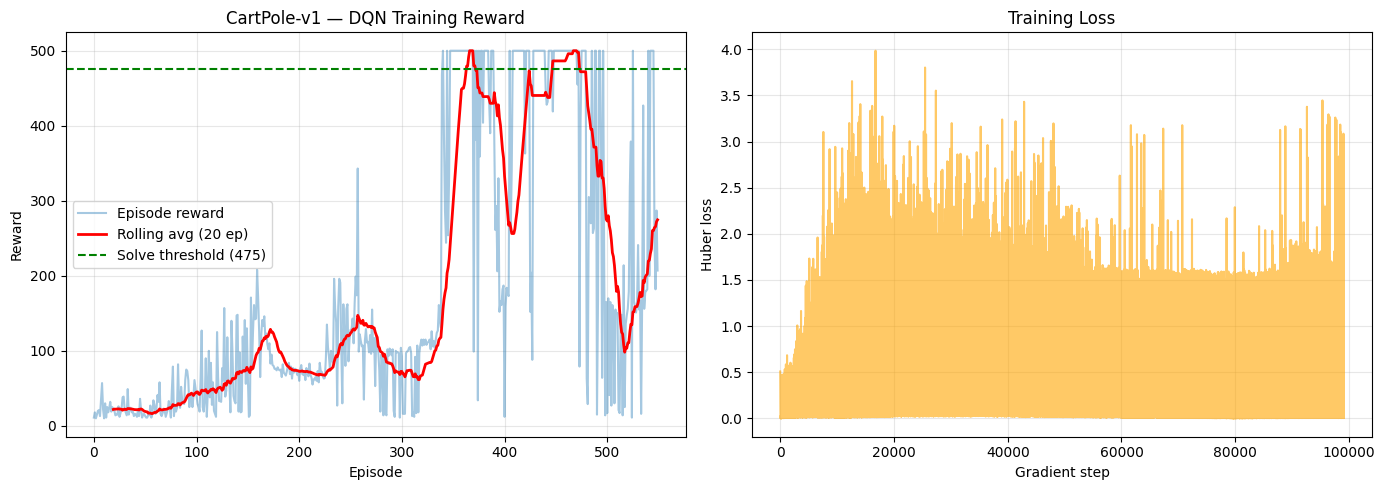

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(episode_rewards, alpha=0.4, label="Episode reward")
if len(episode_rewards) >= 20:
    rolling = np.convolve(episode_rewards, np.ones(20)/20, mode="valid")
    ax[0].plot(range(19, len(episode_rewards)), rolling, color="red", linewidth=2, label="Rolling avg (20 ep)")
ax[0].axhline(SOLVE_SCORE, color="green", linestyle="--", label="Solve threshold (475)")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Reward")
ax[0].set_title("CartPole-v1 — DQN Training Reward")
ax[0].legend()
ax[0].grid(alpha=0.3)

if losses:
    ax[1].plot(losses, alpha=0.6, color="orange")
    ax[1].set_xlabel("Gradient step")
    ax[1].set_ylabel("Huber loss")
    ax[1].set_title("Training Loss")
    ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_curve.png", dpi=120)
plt.show()


## 8. Evaluate the trained policy
Run the trained agent greedily (epsilon = 0) for several episodes and report average reward, to measure the real performance of the learned policy.

In [9]:
def evaluate(agent, n_episodes=20, render=False):
    eval_env = gym.make(ENV_NAME, render_mode="rgb_array" if render else None)
    rewards = []
    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=1000 + ep)
        ep_reward = 0.0
        for _ in range(MAX_STEPS_PER_EP):
            action = agent.select_action(state, greedy=True)
            state, reward, terminated, truncated, _ = eval_env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    eval_env.close()
    return rewards

eval_rewards = evaluate(agent, n_episodes=20)
print("Evaluation rewards (20 greedy episodes):", eval_rewards)
print(f"Mean: {np.mean(eval_rewards):.1f}  |  Std: {np.std(eval_rewards):.1f}  |  Min: {np.min(eval_rewards):.0f}  |  Max: {np.max(eval_rewards):.0f}")


Evaluation rewards (20 greedy episodes): [500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0, 500.0]
Mean: 500.0  |  Std: 0.0  |  Min: 500  |  Max: 500


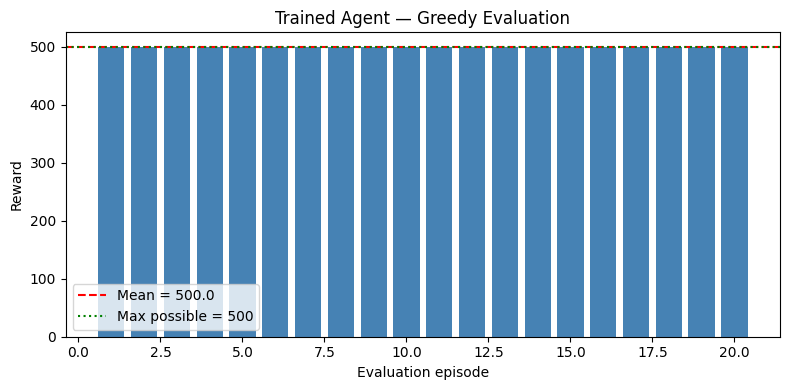

In [10]:
plt.figure(figsize=(8, 4))
plt.bar(range(1, len(eval_rewards) + 1), eval_rewards, color="steelblue")
plt.axhline(np.mean(eval_rewards), color="red", linestyle="--", label=f"Mean = {np.mean(eval_rewards):.1f}")
plt.axhline(500, color="green", linestyle=":", label="Max possible = 500")
plt.xlabel("Evaluation episode")
plt.ylabel("Reward")
plt.title("Trained Agent — Greedy Evaluation")
plt.legend()
plt.tight_layout()
plt.savefig("eval_rewards.png", dpi=120)
plt.show()


## 9. Compare against a random agent
Sanity check to confirm the trained policy is meaningfully better than random actions.

In [11]:
def random_agent_eval(n_episodes=20):
    eval_env = gym.make(ENV_NAME)
    rewards = []
    for ep in range(n_episodes):
        state, _ = eval_env.reset(seed=2000 + ep)
        ep_reward = 0.0
        for _ in range(MAX_STEPS_PER_EP):
            action = eval_env.action_space.sample()
            state, reward, terminated, truncated, _ = eval_env.step(action)
            ep_reward += reward
            if terminated or truncated:
                break
        rewards.append(ep_reward)
    eval_env.close()
    return rewards

random_rewards = random_agent_eval(20)
print(f"Random agent   -> mean reward: {np.mean(random_rewards):.1f}")
print(f"Trained DQN    -> mean reward: {np.mean(eval_rewards):.1f}")
print(f"Improvement    -> {np.mean(eval_rewards) - np.mean(random_rewards):.1f} "
      f"({(np.mean(eval_rewards) / max(np.mean(random_rewards),1e-6) - 1) * 100:.0f}% better)")


Random agent   -> mean reward: 19.9
Trained DQN    -> mean reward: 500.0
Improvement    -> 480.1 (2406% better)


## 10. Save the trained model
Save the policy network's weights so it can be reloaded later without retraining.

In [12]:
torch.save(agent.policy_net.state_dict(), "dqn_cartpole_policy.pt")
print("Saved model weights to dqn_cartpole_policy.pt")

# Quick reload sanity check
loaded_net = QNetwork(state_dim, action_dim).to(device)
loaded_net.load_state_dict(torch.load("dqn_cartpole_policy.pt", map_location=device))
loaded_net.eval()
print("Reload check OK:", type(loaded_net))


Saved model weights to dqn_cartpole_policy.pt
Reload check OK: <class '__main__.QNetwork'>


## Summary

- Implemented a **Double DQN agent from scratch** (Q-network, target network, replay buffer, epsilon-greedy exploration, Huber loss, gradient clipping) using PyTorch and `gymnasium`.
- Trained it on `CartPole-v1` for a fixed number of episodes, tracking reward and loss curves.
- Evaluated the **greedy** (epsilon = 0) policy over 20 episodes and compared it against a random-action baseline.
- Saved the trained weights to `dqn_cartpole_policy.pt` for reuse.

### Ideas to push performance further
- Dueling network architecture (separate value and advantage streams)
- Prioritized experience replay (sample transitions with high TD-error more often)
- Longer training / hyperparameter tuning (learning rate, network size, decay schedule)
- Averaging/checkpointing the best-performing policy seen during training, since DQN performance can still oscillate episode-to-episode even with Double DQN
